# Part 1: Data Loading and Exploratory Data Analysis
## UTD-MHAD — Multimodal Human Activity Recognition

This notebook loads the UTD-MHAD dataset (RGB video + inertial sensor modalities), performs exploratory data analysis, and documents potential data issues relevant to a deployed system.

**Dataset overview:**
- 27 action classes, 8 subjects, 4 trials each → 861 sequences (3 corrupted removed from 864)
- RGB video: `.avi` files, 640×480 @ 15fps (documentation states ~30fps, actual data is 15fps)
- Inertial sensor: `.mat` files, 6-axis (3-axis accel + 3-axis gyro) @ 50Hz
- Sensor placement: wrist for actions 1–21, thigh for actions 22–27

In [1]:
import os
import re
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2                    # OpenCV — used to read video files and extract frame info
from scipy.io import loadmat  # reads MATLAB .mat files (the inertial sensor data format)
from tqdm import tqdm          # progress bars for long loops

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
%matplotlib inline

# --- Paths to the two modality folders inside data/ ---
DATA_DIR = Path('../data')
RGB_DIR = DATA_DIR / 'RGB'          # contains .avi video files
INERTIAL_DIR = DATA_DIR / 'Inertial' # contains .mat inertial sensor files

# Human-readable names for the 27 action classes (action ID → name)
ACTION_NAMES = {
    1: 'Swipe Left', 2: 'Swipe Right', 3: 'Wave', 4: 'Clap',
    5: 'Throw', 6: 'Arm Cross', 7: 'Basketball Shoot',
    8: 'Draw X', 9: 'Draw Circle CW', 10: 'Draw Circle CCW',
    11: 'Draw Triangle', 12: 'Bowling', 13: 'Boxing',
    14: 'Baseball Swing', 15: 'Tennis Swing', 16: 'Arm Curl',
    17: 'Tennis Serve', 18: 'Push', 19: 'Knock',
    20: 'Catch', 21: 'Pickup & Throw', 22: 'Jog', 23: 'Walk',
    24: 'Sit to Stand', 25: 'Stand to Sit',
    26: 'Lunge', 27: 'Squat'
}

# Where the inertial sensor was placed for each action:
#   actions 1-21  → wrist (arm-based actions)
#   actions 22-27 → thigh (leg-based actions)
SENSOR_PLACEMENT = {i: 'wrist' for i in range(1, 22)}
SENSOR_PLACEMENT.update({i: 'thigh' for i in range(22, 28)})

# Sanity-check that the data directories exist
print(f'RGB directory: {RGB_DIR} — exists: {RGB_DIR.exists()}')
print(f'Inertial directory: {INERTIAL_DIR} — exists: {INERTIAL_DIR.exists()}')

RGB directory: ../data/RGB — exists: True
Inertial directory: ../data/Inertial — exists: True


---
## 1. Data Loading

Parse filenames (`aX_sY_tZ_modality`) to extract metadata, then load video properties and inertial signal lengths.

In [3]:
# Regex to extract (action, subject, trial) from filenames like "a1_s2_t3_color.avi"
#   a(\d+) → action number,  s(\d+) → subject number,  t(\d+) → trial number
FILENAME_PATTERN = re.compile(r'a(\d+)_s(\d+)_t(\d+)_')

def parse_filename(fname):
    """Return (action, subject, trial) tuple from a filename, or None if it doesn't match."""
    m = FILENAME_PATTERN.match(fname)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))
    return None

# List all .avi (RGB video) and .mat (inertial sensor) files
rgb_files = sorted(RGB_DIR.glob('*.avi'))
inertial_files = sorted(INERTIAL_DIR.glob('*.mat'))

# Build lookup dictionaries:  (action, subject, trial) → file path
# This lets us quickly find the file for any given sample
rgb_index = {}
for f in rgb_files:
    key = parse_filename(f.name)
    if key:
        rgb_index[key] = f

inertial_index = {}
for f in inertial_files:
    key = parse_filename(f.name)
    if key:
        inertial_index[key] = f

# Union of all keys from both modalities (in case some samples only have one modality)
all_keys = sorted(set(rgb_index.keys()) | set(inertial_index.keys()))
print(f'RGB files: {len(rgb_files)}')
print(f'Inertial files: {len(inertial_files)}')
print(f'Unique (action, subject, trial) keys: {len(all_keys)}')
# Example: Given a sample filename, parse out (action, subject, trial)
print("****************************************************")
print("Parsed example:")
print("****************************************************")
example_file = "a3_s7_t2_color.avi"
example_key = parse_filename(example_file)
print(f"For filename '{example_file}', parsed key = {example_key}")

RGB files: 861
Inertial files: 861
Unique (action, subject, trial) keys: 861
****************************************************
Parsed example:
****************************************************
For filename 'a3_s7_t2_color.avi', parsed key = (3, 7, 2)


In [5]:
# Build a master DataFrame: one row per sample, with metadata from both modalities.
# For each sample we extract:
#   - RGB side:      frame count, fps, resolution, duration (from AVI header via OpenCV)
#   - Inertial side: number of time-steps, number of channels, duration (rows / 50Hz)

records = []

for key in tqdm(all_keys, desc='Loading metadata'):
    action, subject, trial = key
    rec = {
        'action': action,
        'subject': subject,
        'trial': trial,
        'action_name': ACTION_NAMES.get(action, f'Action {action}'),
        'sensor_placement': SENSOR_PLACEMENT.get(action, 'unknown'),
        'has_rgb': key in rgb_index,        # True if an .avi exists for this sample
        'has_inertial': key in inertial_index, # True if a .mat exists for this sample
    }

    # --- Extract RGB video metadata ---
    if rec['has_rgb']:
        # cv2.VideoCapture opens the video; cap.get() reads header properties
        # without decoding any actual frames (fast)
        cap = cv2.VideoCapture(str(rgb_index[key]))
        rec['rgb_frames'] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # total number of frames
        rec['rgb_fps'] = cap.get(cv2.CAP_PROP_FPS)                  # frames per second
        rec['rgb_width'] = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))   # horizontal resolution
        rec['rgb_height'] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # vertical resolution
        rec['rgb_duration'] = rec['rgb_frames'] / rec['rgb_fps'] if rec['rgb_fps'] > 0 else 0  # seconds
        cap.release()
    else:
        rec['rgb_frames'] = 0
        rec['rgb_fps'] = 0
        rec['rgb_width'] = 0
        rec['rgb_height'] = 0
        rec['rgb_duration'] = 0

    # --- Extract inertial sensor metadata ---
    if rec['has_inertial']:
        # loadmat reads a MATLAB .mat file into a dict of numpy arrays.
        # The inertial data is stored under a key like 'd_iner' — a 2D array
        # with shape (time_steps, 6): columns are [accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z]
        mat = loadmat(str(inertial_index[key]))
        # Try known key names first, then fall back to finding any 2D array
        d_inertial = mat.get('d_iner', mat.get('d_inertial', None))
        if d_inertial is None:
            for k, v in mat.items():
                if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim == 2:
                    d_inertial = v
                    break
        if d_inertial is not None:
            rec['inertial_length'] = d_inertial.shape[0]      # number of time-steps (rows)
            rec['inertial_channels'] = d_inertial.shape[1]     # should be 6 (3 accel + 3 gyro)
            rec['inertial_duration'] = d_inertial.shape[0] / 50.0  # duration in seconds (50 Hz sampling)
        else:
            rec['inertial_length'] = 0
            rec['inertial_channels'] = 0
            rec['inertial_duration'] = 0
    else:
        rec['inertial_length'] = 0
        rec['inertial_channels'] = 0
        rec['inertial_duration'] = 0

    records.append(rec)

df = pd.DataFrame(records)
print(f'\nMaster DataFrame: {df.shape[0]} samples, {df.shape[1]} columns')
df.head(10)

Loading metadata: 100%|██████████| 861/861 [00:01<00:00, 587.82it/s]


Master DataFrame: 861 samples, 15 columns


,action,subject,trial,action_name,sensor_placement,has_rgb,has_inertial,rgb_frames,rgb_fps,rgb_width,rgb_height,rgb_duration,inertial_length,inertial_channels,inertial_duration
0,1,1,1,Swipe Left,wrist,True,True,42,15.0,640,480,2.800000,160,6,3.20
1,1,1,2,Swipe Left,wrist,True,True,38,15.0,640,480,2.533333,154,6,3.08
2,1,1,3,Swipe Left,wrist,True,True,45,15.0,640,480,3.000000,165,6,3.30
3,1,1,4,Swipe Left,wrist,True,True,44,15.0,640,480,2.933333,158,6,3.16
4,1,2,1,Swipe Left,wrist,True,True,42,15.0,640,480,2.800000,142,6,2.84
5,1,2,2,Swipe Left,wrist,True,True,49,15.0,640,480,3.266667,156,6,3.12
6,1,2,3,Swipe Left,wrist,True,True,44,15.0,640,480,2.933333,143,6,2.86
7,1,2,4,Swipe Left,wrist,True,True,44,15.0,640,480,2.933333,157,6,3.14
8,1,3,1,Swipe Left,wrist,True,True,44,15.0,640,480,2.933333,146,6,2.92
9,1,3,2,Swipe Left,wrist,True,True,39,15.0,640,480,2.600000,127,6,2.54


In [7]:
# High-level summary: verify dataset completeness and modality coverage.
# Expected: 27 actions × 8 subjects × 4 trials = 864 samples,
# but 3 are known to be corrupted/deleted → 861 expected.
print('=== Dataset Summary ===')
print(f'Total samples: {len(df)}')
print(f'Actions: {df["action"].nunique()} (range {df["action"].min()}–{df["action"].max()})')
print(f'Subjects: {df["subject"].nunique()} (range {df["subject"].min()}–{df["subject"].max()})')
print(f'\nSamples with RGB: {df["has_rgb"].sum()}')
print(f'Samples with Inertial: {df["has_inertial"].sum()}')
print(f'Samples with BOTH modalities: {(df["has_rgb"] & df["has_inertial"]).sum()}')
print(f'Samples MISSING a modality: {(~df["has_rgb"] | ~df["has_inertial"]).sum()}')
print(f'\nExpected total: 27 actions × 8 subjects × 4 trials = {27*8*4}')
print(f'Missing from expected: {27*8*4 - len(df)} (3 corrupted sequences known)')

=== Dataset Summary ===
Total samples: 861
Actions: 27 (range 1–27)
Subjects: 8 (range 1–8)

Samples with RGB: 861
Samples with Inertial: 861
Samples with BOTH modalities: 861
Samples MISSING a modality: 0

Expected total: 27 actions × 8 subjects × 4 trials = 864
Missing from expected: 3 (3 corrupted sequences known)


---
## 2. Class and Subject Distribution

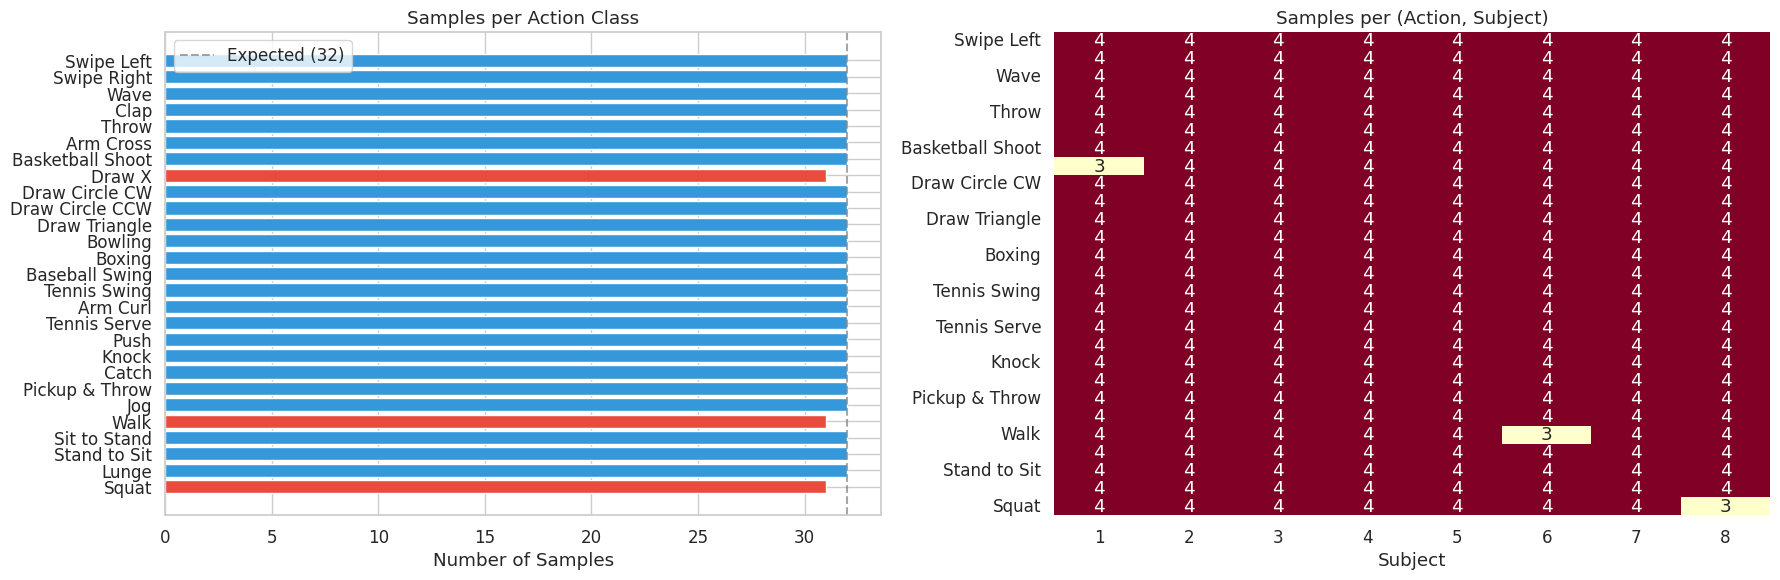


Action-subject combinations with fewer than 4 trials (3): 
  Draw X, Subject 1: 3 trials
  Walk, Subject 6: 3 trials
  Squat, Subject 8: 3 trials


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# LEFT: Horizontal bar chart showing how many samples exist for each action class.
# Each action should have 8 subjects × 4 trials = 32 samples; bars colored red if below 32.
action_counts = df.groupby('action').size().reset_index(name='count')
action_counts['label'] = action_counts['action'].map(ACTION_NAMES)
colors = ['#e74c3c' if c < 32 else '#3498db' for c in action_counts['count']]
axes[0].barh(action_counts['label'], action_counts['count'], color=colors)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Samples per Action Class')
axes[0].axvline(x=32, color='gray', linestyle='--', alpha=0.7, label='Expected (32)')
axes[0].legend()
axes[0].invert_yaxis()

# RIGHT: Heatmap of (action × subject) showing trial counts.
# Most cells should be 4 (4 trials); cells with fewer indicate missing/corrupted data.
pivot = df.groupby(['action', 'subject']).size().unstack(fill_value=0)
pivot.index = [ACTION_NAMES[a] for a in pivot.index]
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            cbar=False)
axes[1].set_title('Samples per (Action, Subject)')
axes[1].set_ylabel('')
axes[1].set_xlabel('Subject')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Report which (action, subject) combinations have fewer than 4 trials (the corrupted ones)
missing_locs = [(r, c) for r in pivot.index for c in pivot.columns if pivot.loc[r, c] < 4]
if missing_locs:
    print(f'\nAction-subject combinations with fewer than 4 trials ({len(missing_locs)}): ')
    for action_name, subj in missing_locs:
        print(f'  {action_name}, Subject {subj}: {pivot.loc[action_name, subj]} trials')
else:
    print('\nAll action-subject combinations have the expected 4 trials.')

**Data Issue — Corrupted/Missing Samples:** The heatmap above reveals 3 (action, subject) pairs with only 3 trials instead of 4 — these correspond to the 3 corrupted sequences removed from the original 864. This is a minor imbalance, but in a deployed system, the data pipeline must gracefully handle missing or corrupted files (e.g., a camera that fails to record, or a sensor that disconnects mid-trial).

**Data Issue — Limited Subject Diversity:** With only 8 subjects (4 male, 4 female), the dataset has very limited demographic coverage. Each subject's unique body proportions, movement speed, and personal style are heavily represented. A model trained on this data risks overfitting to these 8 individuals and may fail to generalize to new users with different body types, ages, or mobility levels.

**Data Issue — Class Similarity:** Some action classes are kinematically very similar — for example, Swipe Left vs. Swipe Right are mirror images, Draw Circle CW vs. CCW differ only in rotation direction, and Jog vs. Walk differ mainly in speed. These visually/kinematically similar pairs are likely to confuse a classifier, especially from inertial data alone. Fine-grained temporal features or multimodal fusion may be needed to disambiguate them.

---
## 3. Temporal Statistics

Analyzing the distribution of sequence lengths across modalities and action classes.

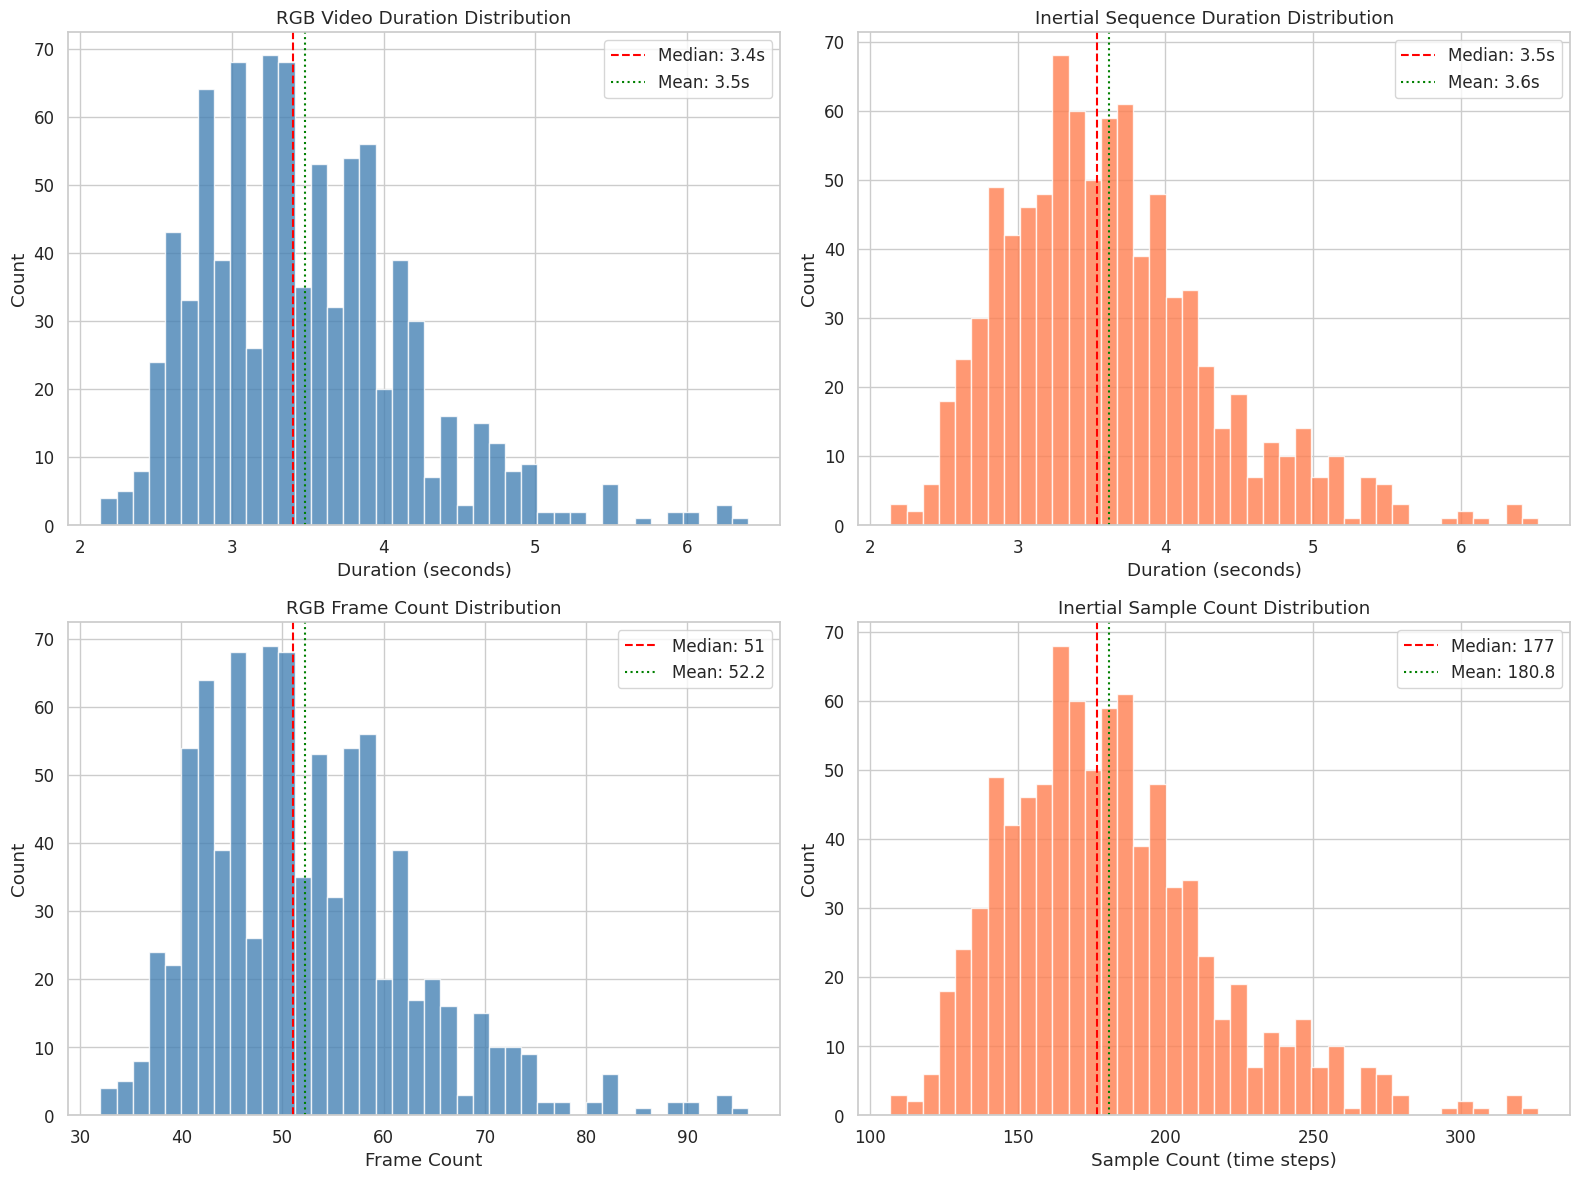


=== Duration statistics ===
RGB duration  — min: 2.13s, max: 6.40s, mean: 3.48s, median: 3.40s, std: 0.69s
Inertial dur. — min: 2.14s, max: 6.52s, mean: 3.62s, median: 3.54s, std: 0.71s
RGB frames    — min: 32, max: 96, mean: 52.24, median: 51.00, std: 10.32
Inertial len. — min: 107, max: 326, mean: 180.76, median: 177.00, std: 35.38

Ratio max/min duration — RGB: 3.0x, Inertial: 3.0x


In [10]:
# 2×2 grid of histograms showing the distribution of sequence lengths for both modalities.
# Top row: duration in seconds.  Bottom row: raw sample counts (frames / time-steps).
# This reveals how variable the sequence lengths are — important for choosing a
# padding/truncation strategy later.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: how long each RGB video is (in seconds)
axes[0, 0].hist(df['rgb_duration'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('RGB Video Duration Distribution')
median_rgb = df['rgb_duration'].median()
mean_rgb = df['rgb_duration'].mean()
axes[0, 0].axvline(median_rgb, color='red', linestyle='--', label=f'Median: {median_rgb:.1f}s')
axes[0, 0].axvline(mean_rgb, color='green', linestyle=':', label=f'Mean: {mean_rgb:.1f}s')
axes[0, 0].legend()

# Top-right: how long each inertial recording is (in seconds)
axes[0, 1].hist(df['inertial_duration'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0, 1].set_xlabel('Duration (seconds)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Inertial Sequence Duration Distribution')
median_inertial = df['inertial_duration'].median()
mean_inertial = df['inertial_duration'].mean()
axes[0, 1].axvline(median_inertial, color='red', linestyle='--', label=f'Median: {median_inertial:.1f}s')
axes[0, 1].axvline(mean_inertial, color='green', linestyle=':', label=f'Mean: {mean_inertial:.1f}s')
axes[0, 1].legend()

# Bottom-left: number of frames in each RGB video
axes[1, 0].hist(df['rgb_frames'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 0].set_xlabel('Frame Count')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('RGB Frame Count Distribution')
median_rgb_frames = df['rgb_frames'].median()
mean_rgb_frames = df['rgb_frames'].mean()
axes[1, 0].axvline(median_rgb_frames, color='red', linestyle='--', label=f'Median: {median_rgb_frames:.0f}')
axes[1, 0].axvline(mean_rgb_frames, color='green', linestyle=':', label=f'Mean: {mean_rgb_frames:.1f}')
axes[1, 0].legend()

# Bottom-right: number of time-steps in each inertial recording
axes[1, 1].hist(df['inertial_length'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1, 1].set_xlabel('Sample Count (time steps)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Inertial Sample Count Distribution')
median_inertial_len = df['inertial_length'].median()
mean_inertial_len = df['inertial_length'].mean()
axes[1, 1].axvline(median_inertial_len, color='red', linestyle='--', label=f'Median: {median_inertial_len:.0f}')
axes[1, 1].axvline(mean_inertial_len, color='green', linestyle=':', label=f'Mean: {mean_inertial_len:.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../data/temporal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print min/max/mean/std and the ratio between longest and shortest sequences
print('\n=== Duration statistics ===')
print(f'RGB duration  — min: {df["rgb_duration"].min():.2f}s, max: {df["rgb_duration"].max():.2f}s, '
      f'mean: {df["rgb_duration"].mean():.2f}s, median: {df["rgb_duration"].median():.2f}s, std: {df["rgb_duration"].std():.2f}s')
print(f'Inertial dur. — min: {df["inertial_duration"].min():.2f}s, max: {df["inertial_duration"].max():.2f}s, '
      f'mean: {df["inertial_duration"].mean():.2f}s, median: {df["inertial_duration"].median():.2f}s, std: {df["inertial_duration"].std():.2f}s')
print(f'RGB frames    — min: {df["rgb_frames"].min()}, max: {df["rgb_frames"].max()}, '
      f'mean: {df["rgb_frames"].mean():.2f}, median: {df["rgb_frames"].median():.2f}, std: {df["rgb_frames"].std():.2f}')
print(f'Inertial len. — min: {df["inertial_length"].min()}, max: {df["inertial_length"].max()}, '
      f'mean: {df["inertial_length"].mean():.2f}, median: {df["inertial_length"].median():.2f}, std: {df["inertial_length"].std():.2f}')
print(f'\nRatio max/min duration — RGB: {df["rgb_duration"].max()/max(df["rgb_duration"].min(),0.01):.1f}x, '
      f'Inertial: {df["inertial_duration"].max()/max(df["inertial_duration"].min(),0.01):.1f}x')

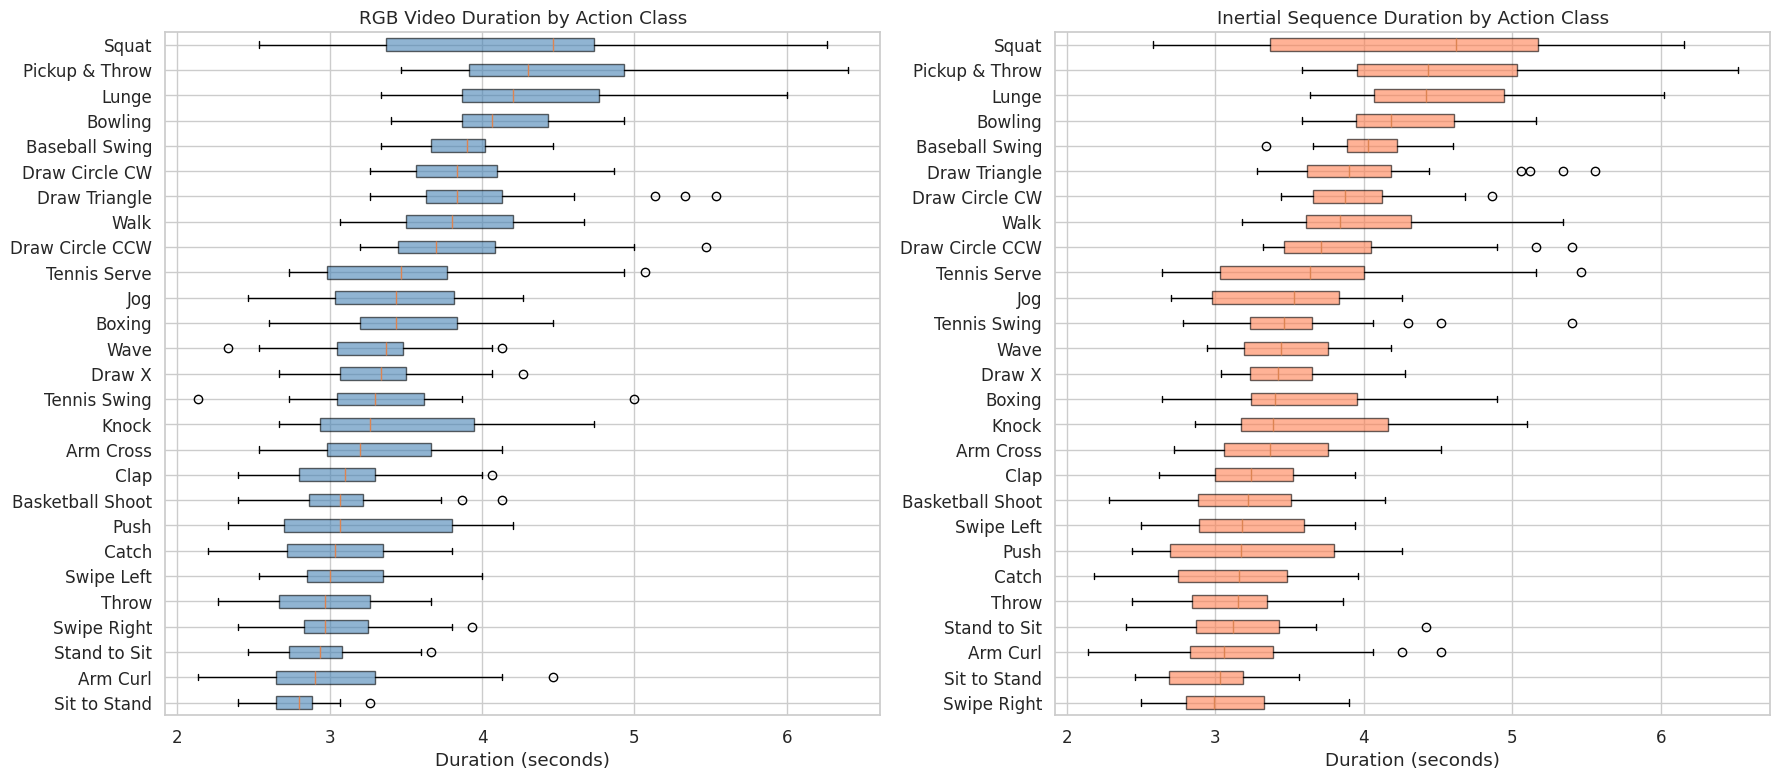


Actions with highest duration variability (CV = std/mean):
                    mean       std        cv
Squat           4.202151  0.999182  0.237779
Tennis Serve    3.564583  0.698177  0.195865
Push            3.185417  0.609303  0.191279
Pickup & Throw  4.504167  0.839685  0.186424
Arm Curl        3.018750  0.546670  0.181092
Knock           3.512500  0.632555  0.180087
Lunge           4.331250  0.700943  0.161834
Catch           3.041667  0.447294  0.147055
Tennis Swing    3.343750  0.479877  0.143515
Jog             3.427083  0.491610  0.143448


In [7]:
# Box plots: duration broken down per action class, sorted by median duration.
# This shows which actions are quick vs slow and how much intra-class variability exists.
# High variability within an action → harder to pick a fixed input length.
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LEFT: RGB video durations per action (sorted by median, shortest at top)
order = df.groupby('action')['rgb_duration'].median().sort_values().index
labels = [ACTION_NAMES[a] for a in order]
data_groups = [df[df['action'] == a]['rgb_duration'].values for a in order]
bp1 = axes[0].boxplot(data_groups, vert=False, labels=labels, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_title('RGB Video Duration by Action Class')

# RIGHT: Inertial sequence durations per action
order2 = df.groupby('action')['inertial_duration'].median().sort_values().index
labels2 = [ACTION_NAMES[a] for a in order2]
data_groups2 = [df[df['action'] == a]['inertial_duration'].values for a in order2]
bp2 = axes[1].boxplot(data_groups2, vert=False, labels=labels2, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.6)
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_title('Inertial Sequence Duration by Action Class')

plt.tight_layout()
plt.savefig('../data/duration_by_action.png', dpi=150, bbox_inches='tight')
plt.show()

# Coefficient of variation (CV = std/mean): measures relative variability.
# High CV means the action duration is very inconsistent across subjects/trials.
cv_by_action = df.groupby('action')['rgb_duration'].agg(['mean','std'])
cv_by_action['cv'] = cv_by_action['std'] / cv_by_action['mean']
cv_by_action.index = [ACTION_NAMES[a] for a in cv_by_action.index]
print('\nActions with highest duration variability (CV = std/mean):')
print(cv_by_action.sort_values('cv', ascending=False).head(10).to_string())

**Data Issue — Variable Sequence Lengths:** The box plots above show that action durations vary significantly — both across classes (e.g., quick claps vs. long squats) and within the same class (high intra-class variability for actions like Squat and Tennis Serve). Durations range from ~2s to ~6.4s (a 3x ratio). In a deployed system, this means we cannot use a fixed-length input without either (a) truncating long sequences (risking loss of discriminative segments), (b) padding short sequences (introducing noise), or (c) using variable-length architectures (e.g., RNNs, attention mechanisms). The coefficient of variation (CV) table shows which actions are most inconsistent in timing.

---
## 4. RGB Video Analysis

Visual inspection of sample frames, resolution consistency, and brightness/contrast.

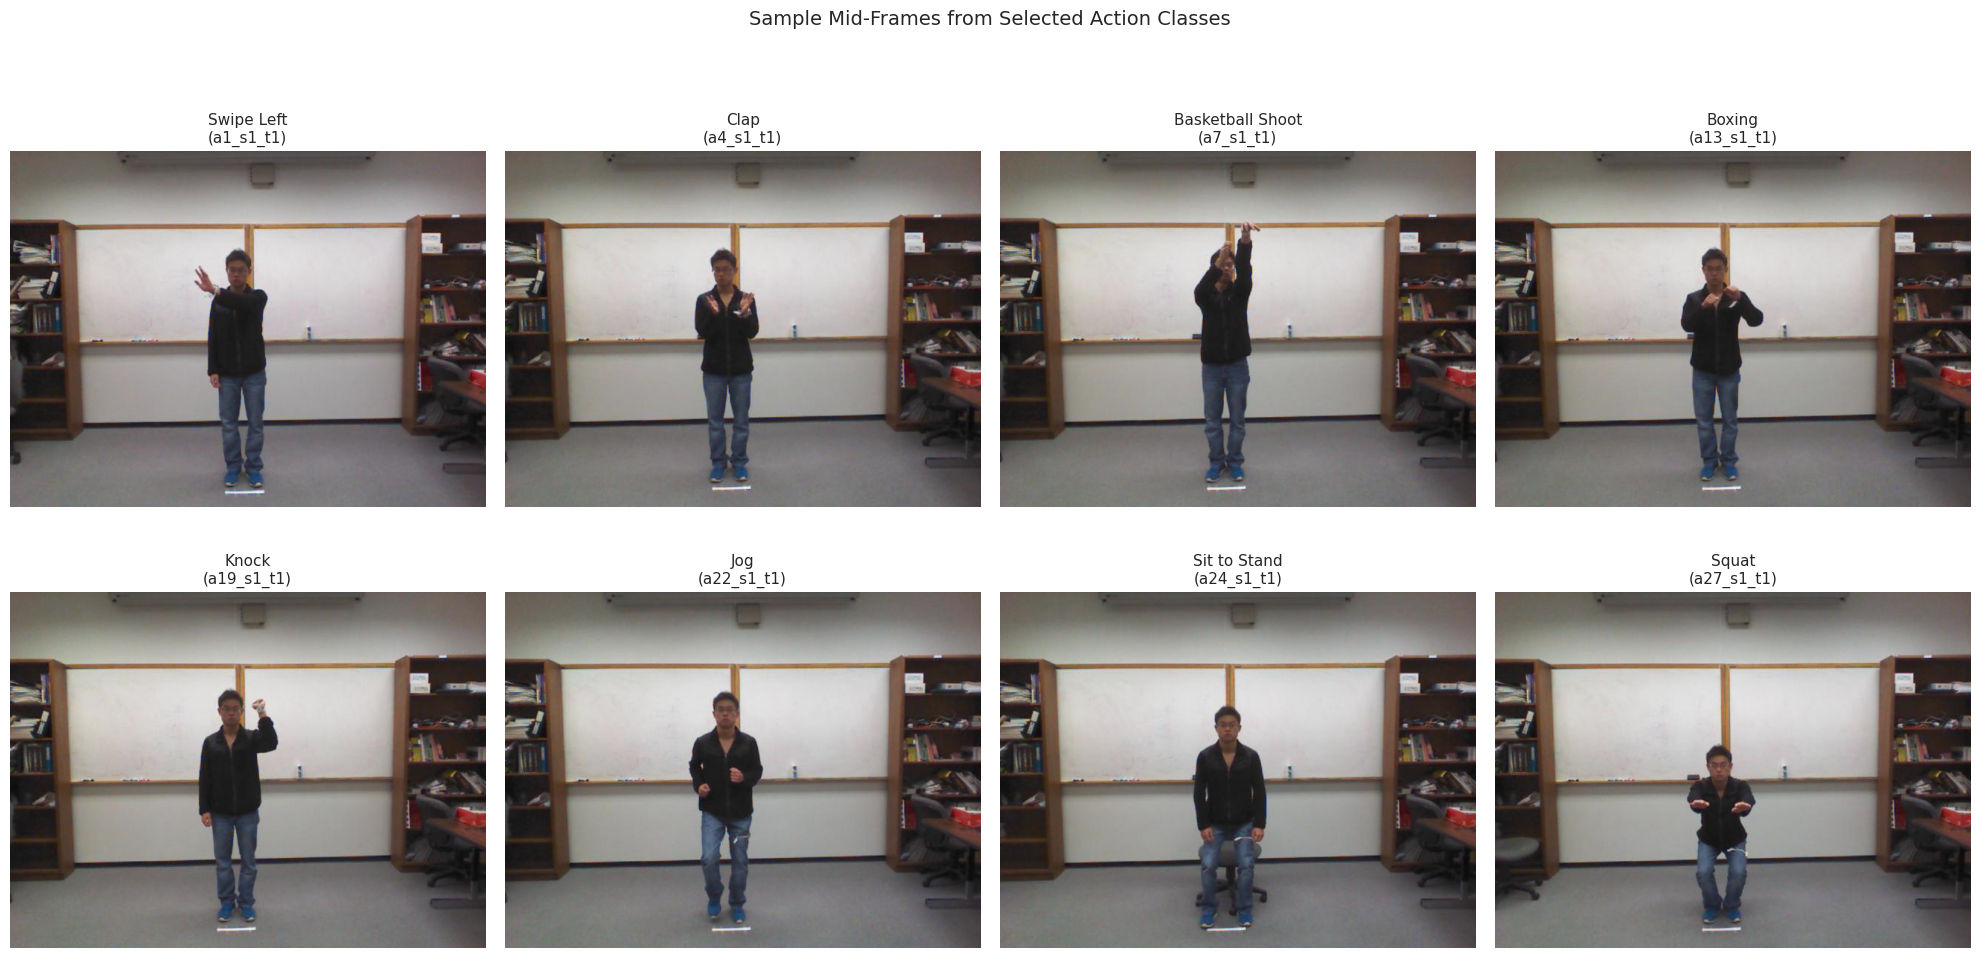

In [8]:
# Display one representative frame from 8 selected action classes.
# For each action we pick subject 1, trial 1, and extract the middle frame
# to see what the action looks like at its midpoint.
sample_actions = [1, 4, 7, 13, 19, 22, 24, 27]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, action_id in enumerate(sample_actions):
    row, col = idx // 4, idx % 4
    # Try to use subject 1, trial 1; fall back to any available sample
    sample = df[(df['action'] == action_id) & (df['subject'] == 1) & (df['trial'] == 1)]
    if sample.empty:
        sample = df[df['action'] == action_id].iloc[:1]

    key = (sample.iloc[0]['action'], sample.iloc[0]['subject'], sample.iloc[0]['trial'])
    video_path = rgb_index[key]

    # Open video, seek to the middle frame, read it
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)  # jump to midpoint
    ret, frame = cap.read()
    cap.release()

    if ret:
        # OpenCV reads frames in BGR; convert to RGB for matplotlib display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(frame_rgb)
    axes[row, col].set_title(f'{ACTION_NAMES[action_id]}\n(a{action_id}_s{key[1]}_t{key[2]})', fontsize=11)
    axes[row, col].axis('off')

plt.suptitle('Sample Mid-Frames from Selected Action Classes', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Check whether all videos share the same resolution and frame rate.
# If not, we'd need to resize/resample before batching.
resolutions = df[['rgb_width', 'rgb_height']].drop_duplicates()
print('=== Resolution Consistency ===')
print(f'Unique resolutions: {len(resolutions)}')
for _, row in resolutions.iterrows():
    count = len(df[(df['rgb_width'] == row['rgb_width']) & (df['rgb_height'] == row['rgb_height'])])
    print(f'  {int(row["rgb_width"])}×{int(row["rgb_height"])}: {count} videos')

# Check if FPS is consistent across all videos
fps_values = df['rgb_fps'].unique()
print(f'\nUnique FPS values: {sorted(fps_values)}')
print(f'FPS stats — mean: {df["rgb_fps"].mean():.1f}, std: {df["rgb_fps"].std():.2f}')

=== Resolution Consistency ===
Unique resolutions: 1
  640×480: 861 videos

Unique FPS values: [15.0]
FPS stats — mean: 15.0, std: 0.00


**Data Issue — Different Sampling Rates:** All videos have the same resolution (640x480) and FPS (15), which is good for consistency. However, the RGB frame rate (15 Hz) is very different from the inertial sampling rate (50 Hz). This 1:3.33 ratio means the two modalities cannot be aligned frame-by-frame. In a deployed fusion system, this requires either (a) upsampling the video timestamps, (b) downsampling the inertial data, or (c) using separate encoders per modality with late fusion.

Analyzing brightness: 100%|██████████| 100/100 [00:02<00:00, 35.99it/s]


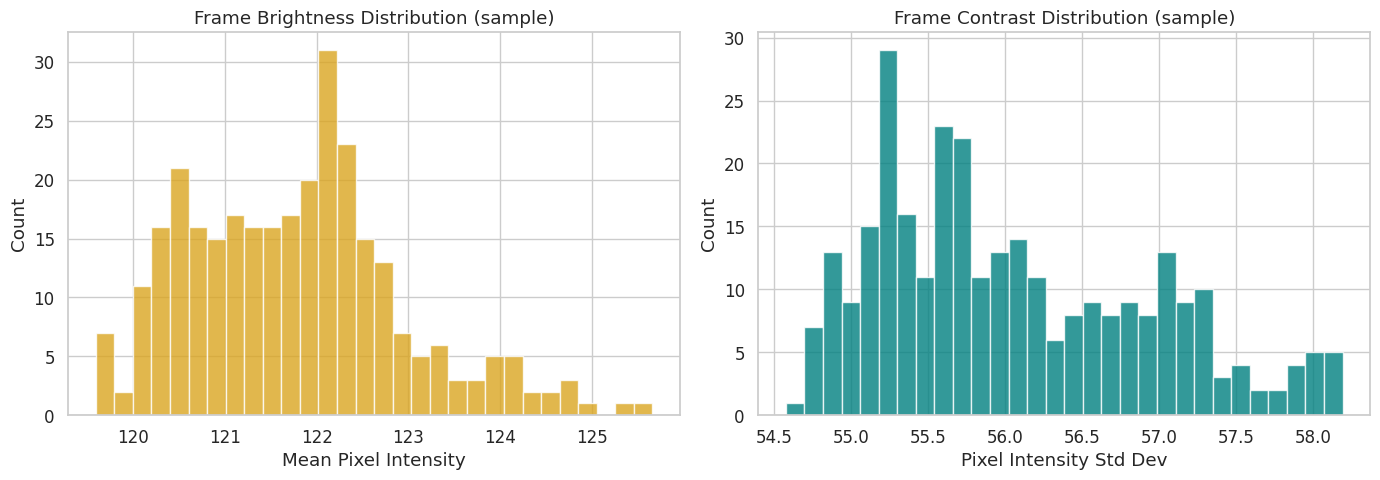

Mean brightness: 121.8 ± 1.2
Low brightness frames (<50): 0
High brightness frames (>200): 0


In [12]:
# Brightness and contrast analysis on a random sample of 100 videos.
# For each video, we sample 3 frames (at 25%, 50%, 75% of the video)
# and compute grayscale pixel statistics.
# - mean_brightness: average pixel intensity (0=black, 255=white)
# - std_brightness:  pixel intensity std dev — a proxy for contrast
# Very low brightness = too dark; very high = washed out.
np.random.seed(42)
sample_indices = np.random.choice(len(all_keys), size=min(100, len(all_keys)), replace=False)
brightness_stats = []

for i in tqdm(sample_indices, desc='Analyzing brightness'):
    key = all_keys[i]
    if key not in rgb_index:
        continue
    cap = cv2.VideoCapture(str(rgb_index[key]))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for frac in [0.25, 0.5, 0.75]:  # sample at quarter, half, three-quarter points
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(total * frac))
        ret, frame = cap.read()
        if ret:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # convert to single-channel grayscale
            brightness_stats.append({
                'action': key[0],
                'mean_brightness': gray.mean(),   # average intensity across all pixels
                'std_brightness': gray.std(),     # spread of pixel values (contrast)
                'min_val': gray.min(),
                'max_val': gray.max(),
            })
    cap.release()

bright_df = pd.DataFrame(brightness_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# LEFT: distribution of mean brightness (are frames consistently lit?)
axes[0].hist(bright_df['mean_brightness'], bins=30, color='goldenrod', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Mean Pixel Intensity')
axes[0].set_ylabel('Count')
axes[0].set_title('Frame Brightness Distribution (sample)')

# RIGHT: distribution of contrast (std dev of pixel values)
axes[1].hist(bright_df['std_brightness'], bins=30, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Pixel Intensity Std Dev')
axes[1].set_ylabel('Count')
axes[1].set_title('Frame Contrast Distribution (sample)')

plt.tight_layout()
plt.savefig('../data/brightness_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean brightness: {bright_df["mean_brightness"].mean():.1f} ± {bright_df["mean_brightness"].std():.1f}')
print(f'Low brightness frames (<50): {(bright_df["mean_brightness"] < 50).sum()}')
print(f'High brightness frames (>200): {(bright_df["mean_brightness"] > 200).sum()}')

**Data Issue — Environment Bias:** The brightness and contrast distributions are tightly clustered, confirming that all recordings were made under the same controlled indoor lighting with a fixed camera angle and clean background. While this makes the dataset internally consistent, it means a deployed model will likely fail when encountering different environments — outdoor settings, varying lighting conditions, cluttered backgrounds, or different camera angles. Data augmentation (brightness/contrast jitter, background replacement) would be needed to improve robustness.

---
## 5. Inertial Signal Analysis

Examining accelerometer and gyroscope signals: time-series plots, per-channel statistics, and sensor anomalies.

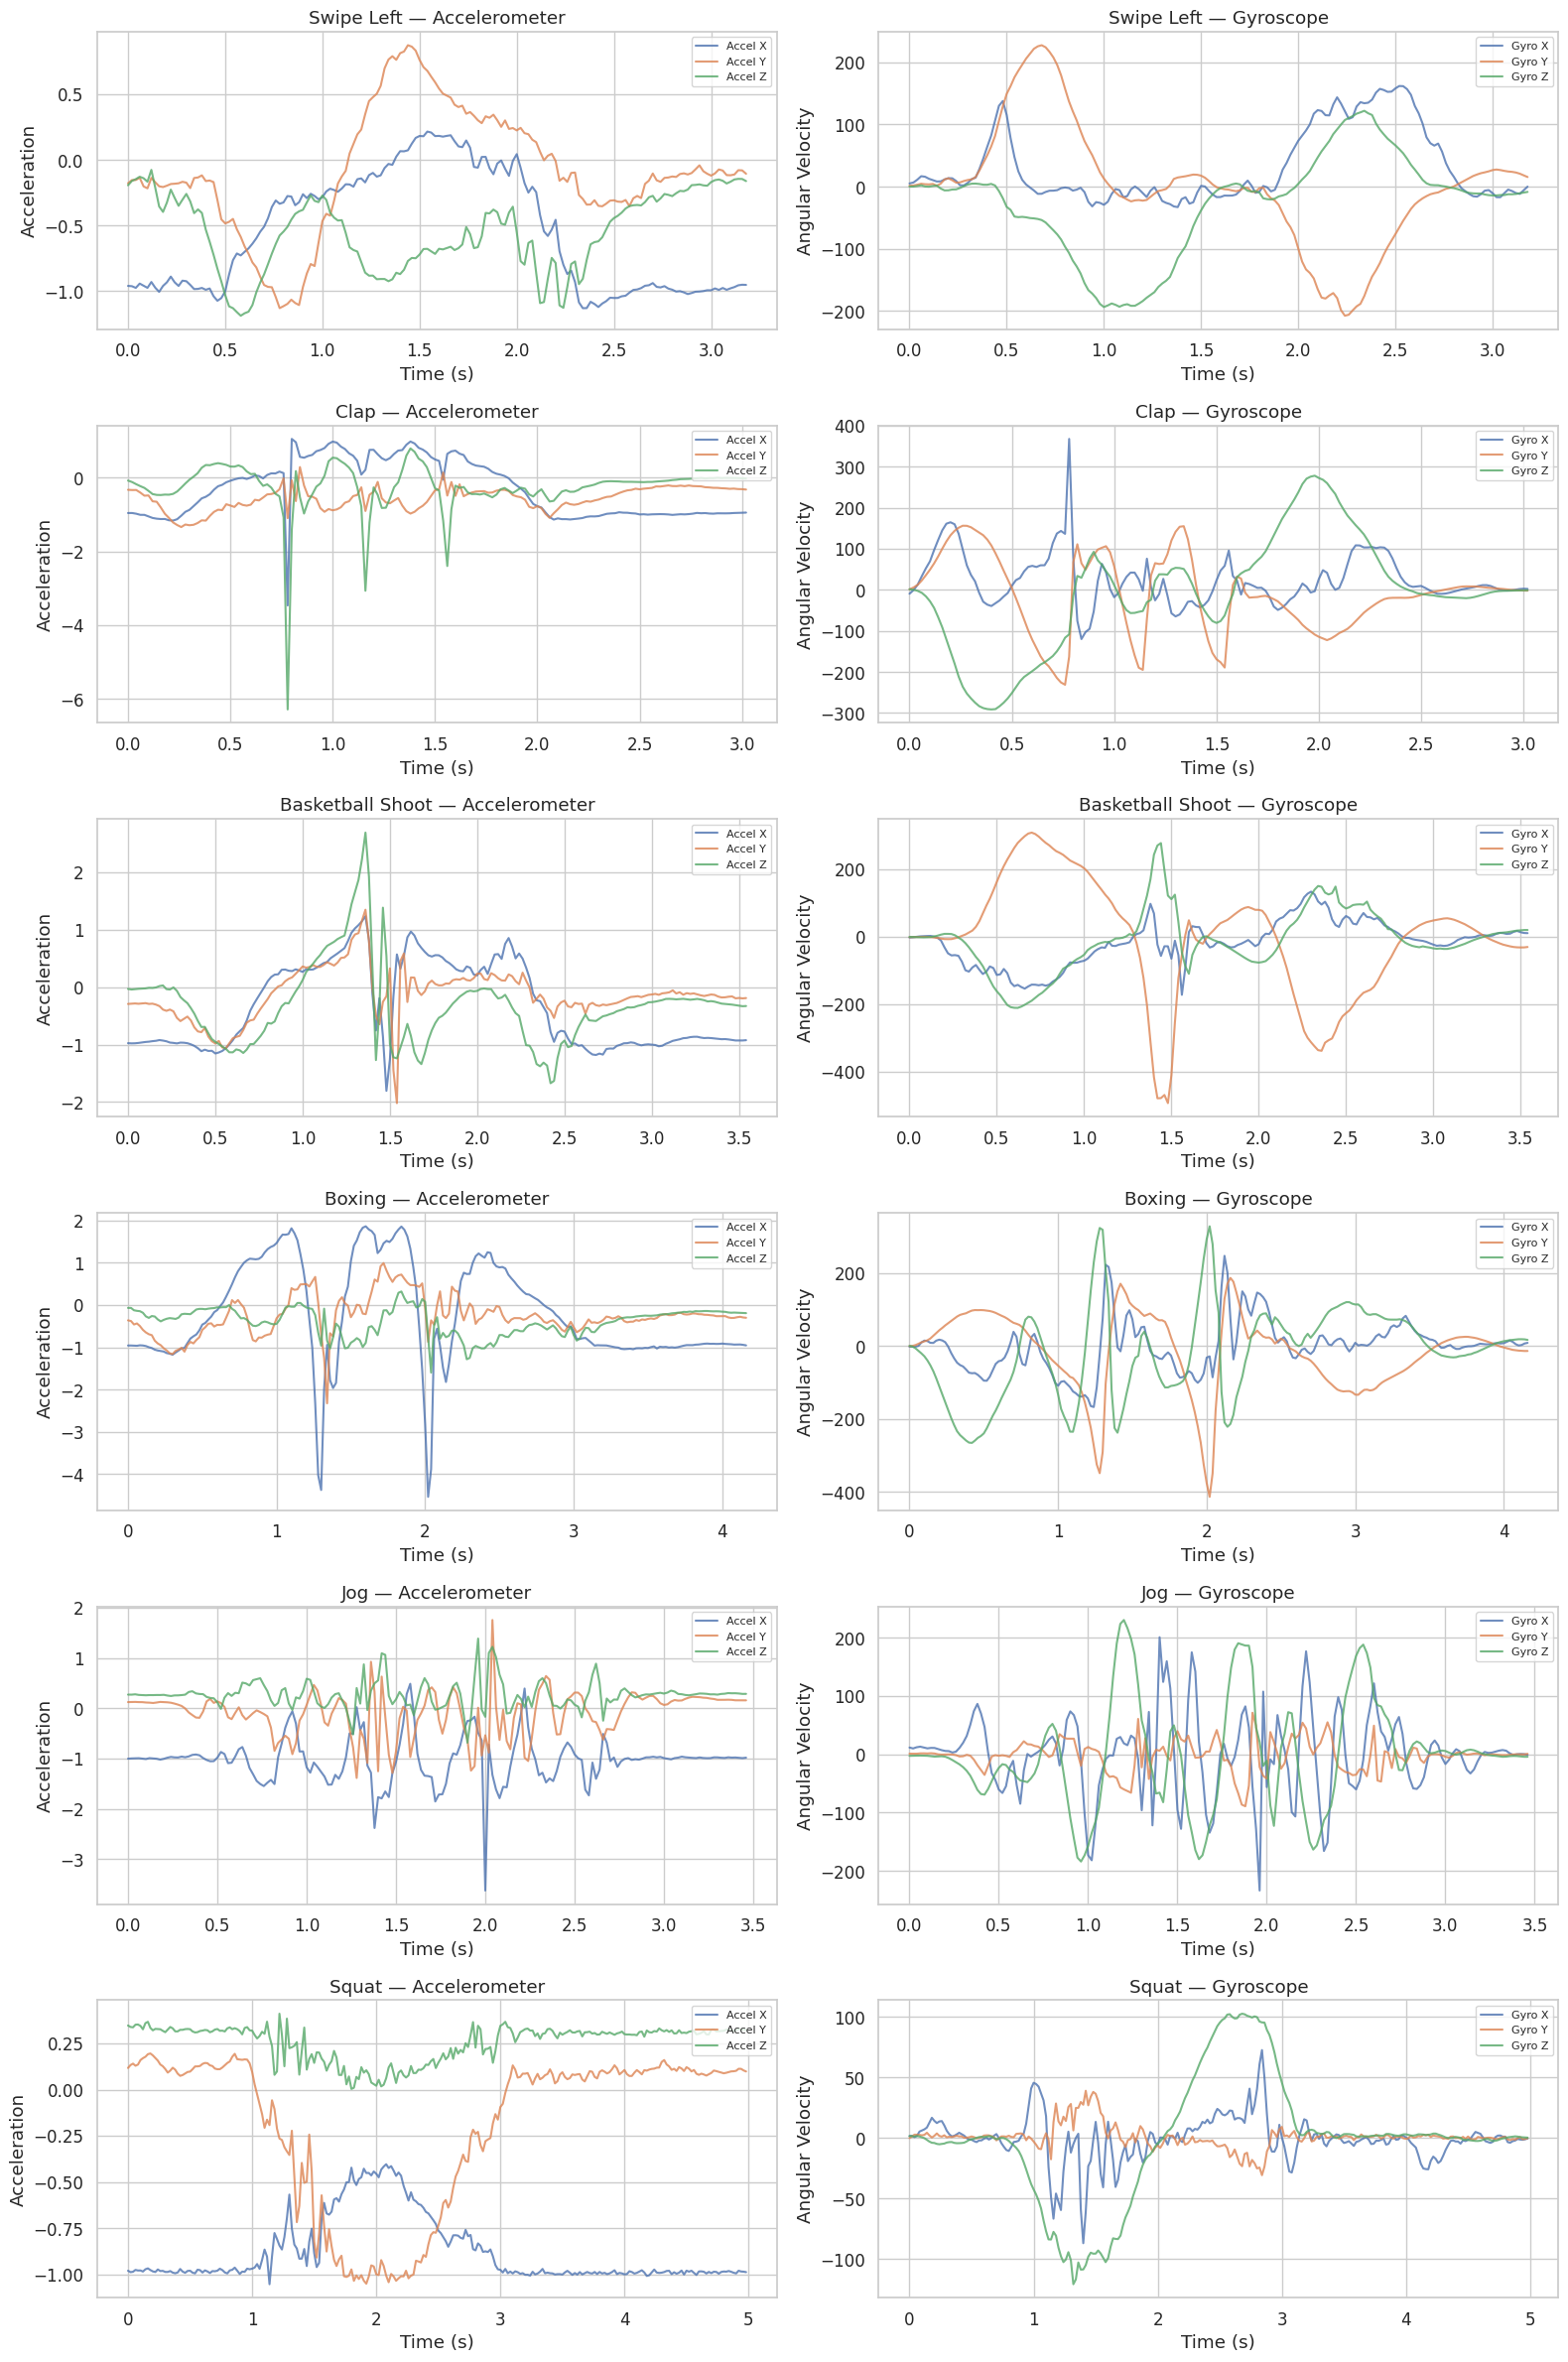

In [14]:
# Plot raw inertial sensor time-series for 6 representative actions.
# Each row = one action, with accelerometer (left) and gyroscope (right).
# The .mat file contains a 2D array: rows = time-steps, columns = [ax, ay, az, gx, gy, gz].
# Time axis is computed from the 50 Hz sampling rate: t = sample_index / 50.
sample_actions_iner = [1, 4, 7, 13, 22, 27]
fig, axes = plt.subplots(len(sample_actions_iner), 2, figsize=(16, 4 * len(sample_actions_iner)))

accel_labels = ['Accel X', 'Accel Y', 'Accel Z']  # columns 0, 1, 2
gyro_labels = ['Gyro X', 'Gyro Y', 'Gyro Z']      # columns 3, 4, 5

for idx, action_id in enumerate(sample_actions_iner):
    # Pick subject 1, trial 1 as the representative example
    sample = df[(df['action'] == action_id) & (df['subject'] == 1) & (df['trial'] == 1)]
    if sample.empty:
        sample = df[df['action'] == action_id].iloc[:1]

    key = (sample.iloc[0]['action'], sample.iloc[0]['subject'], sample.iloc[0]['trial'])
    mat = loadmat(str(inertial_index[key]))
    # Find the 2D data array inside the .mat file (skip MATLAB metadata keys starting with '_')
    d_iner = None
    for k, v in mat.items():
        if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim == 2:
            d_iner = v
            break

    # Convert sample indices to seconds (50 samples/sec)
    t = np.arange(d_iner.shape[0]) / 50.0

    # Plot 3-axis accelerometer on the left
    for ch in range(min(3, d_iner.shape[1])):
        axes[idx, 0].plot(t, d_iner[:, ch], label=accel_labels[ch], alpha=0.8)
    axes[idx, 0].set_title(f'{ACTION_NAMES[action_id]} — Accelerometer')
    axes[idx, 0].set_xlabel('Time (s)')
    axes[idx, 0].set_ylabel('Acceleration')
    axes[idx, 0].legend(loc='upper right', fontsize=8)

    # Plot 3-axis gyroscope on the right
    for ch in range(3, min(6, d_iner.shape[1])):
        axes[idx, 1].plot(t, d_iner[:, ch], label=gyro_labels[ch - 3], alpha=0.8)
    axes[idx, 1].set_title(f'{ACTION_NAMES[action_id]} — Gyroscope')
    axes[idx, 1].set_xlabel('Time (s)')
    axes[idx, 1].set_ylabel('Angular Velocity')
    axes[idx, 1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../data/inertial_signals.png', dpi=150, bbox_inches='tight')
plt.show()

**Data Issue — Sensor Placement Difference:** Comparing the inertial signal plots above, notice how arm actions (e.g., Swipe Left, Clap — sensor on wrist) produce very different accelerometer/gyroscope patterns compared to leg actions (e.g., Jog, Squat — sensor on thigh). The sensor placement fundamentally changes signal characteristics: wrist signals capture hand/arm dynamics, while thigh signals capture leg/body dynamics. In a deployed system, if the sensor placement is inconsistent or unknown, the model must either learn placement-invariant features or explicitly account for placement as an input variable.

In [15]:
# Collect ALL signal values from every sample, grouped by channel (0-5).
# This lets us compute global statistics (mean, std, min, max) for each sensor axis
# and later plot their distributions.
channel_stats = {ch: {'vals': []} for ch in range(6)}
channel_names = accel_labels + gyro_labels  # ['Accel X', ..., 'Gyro Z']

for key in tqdm(all_keys, desc='Computing inertial stats'):
    if key not in inertial_index:
        continue
    mat = loadmat(str(inertial_index[key]))
    d_iner = None
    for k, v in mat.items():
        if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim == 2:
            d_iner = v
            break
    if d_iner is not None:
        # Store each channel's raw values (1D array) for this sample
        for ch in range(min(6, d_iner.shape[1])):
            channel_stats[ch]['vals'].append(d_iner[:, ch])

# Concatenate all samples per channel and compute summary statistics.
# This tells us the typical range of each sensor axis.
print('=== Per-Channel Statistics (across entire dataset) ===')
print(f'{"Channel":<12} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
print('-' * 55)
global_stats = {}
for ch in range(6):
    all_vals = np.concatenate(channel_stats[ch]['vals'])
    global_stats[ch] = {
        'mean': all_vals.mean(), 'std': all_vals.std(),
        'min': all_vals.min(), 'max': all_vals.max()
    }
    print(f'{channel_names[ch]:<12} {all_vals.mean():>10.3f} {all_vals.std():>10.3f} '
          f'{all_vals.min():>10.3f} {all_vals.max():>10.3f}')

Computing inertial stats: 100%|██████████| 861/861 [00:00<00:00, 4124.16it/s]

=== Per-Channel Statistics (across entire dataset) ===
Channel            Mean        Std        Min        Max
-------------------------------------------------------
Accel X          -0.659      0.751     -8.000      3.653
Accel Y          -0.283      0.531     -8.000      7.725
Accel Z          -0.035      0.564     -8.000      6.398
Gyro X            2.889     97.879  -1000.550   1000.519
Gyro Y           -4.796    112.075  -1000.550    606.779
Gyro Z           -0.166    122.685   -741.557   1000.519


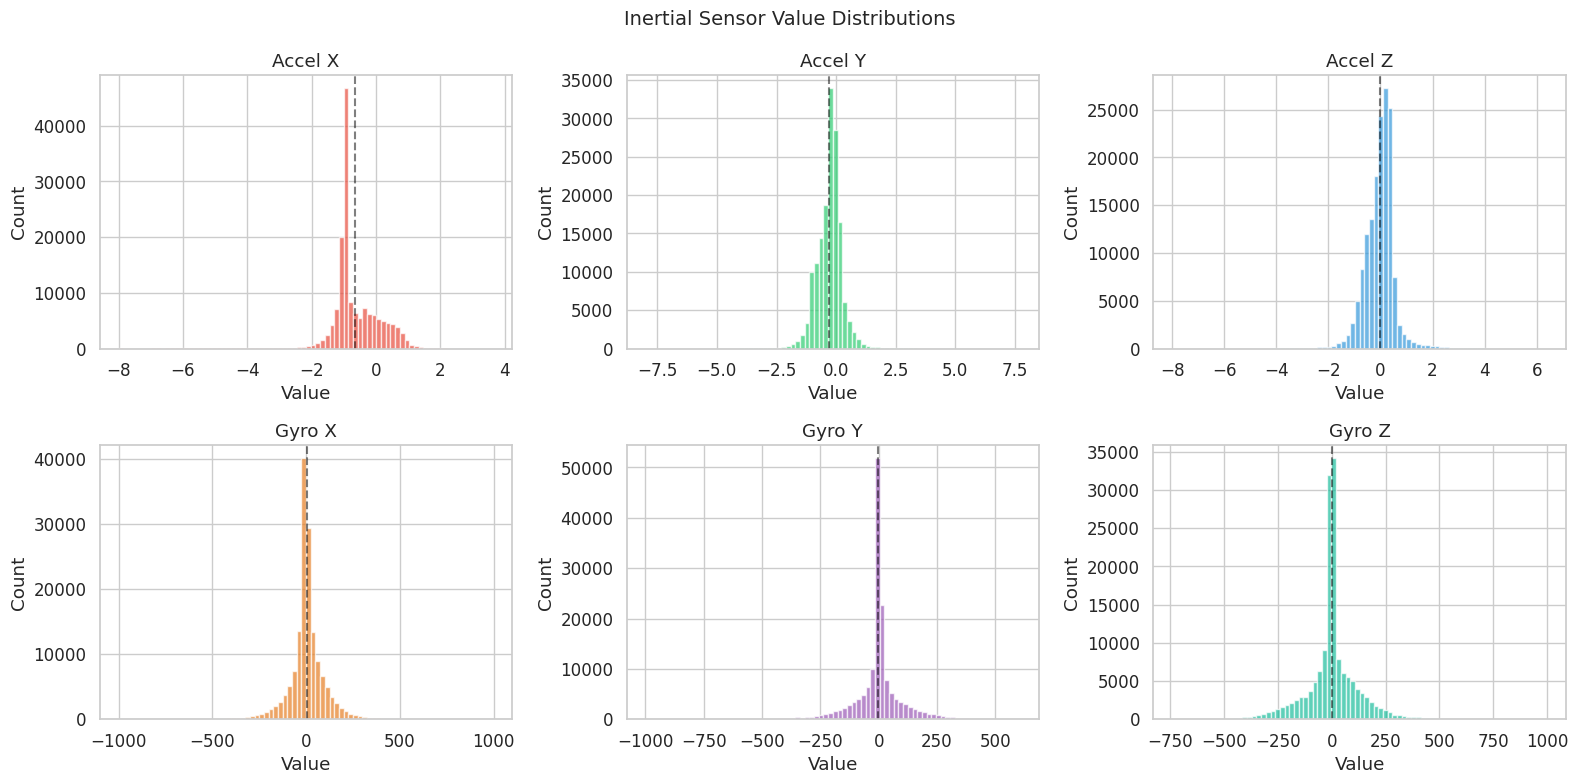


=== Sensor Clipping Check ===
Accelerometer range: ±8g (~±78.4 m/s²)
Gyroscope range: ±1000 deg/s
  Accel X: abs max = 8.00, 0.039% near extremes
  Accel Y: abs max = 8.00, 0.003% near extremes
  Accel Z: abs max = 8.00, 0.003% near extremes
  Gyro X: abs max = 1000.55, 0.011% near extremes
  Gyro Y: abs max = 1000.55, 0.013% near extremes
  Gyro Z: abs max = 1000.52, 0.004% near extremes


In [16]:
# Histograms of all sensor values for each of the 6 channels.
# Top row: accelerometer (X, Y, Z).  Bottom row: gyroscope (X, Y, Z).
# Dashed black line = channel mean.  These show whether the data is centered,
# symmetric, or has heavy tails.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors_ch = ['#e74c3c', '#2ecc71', '#3498db', '#e67e22', '#9b59b6', '#1abc9c']

for ch in range(6):
    row, col = ch // 3, ch % 3
    all_vals = np.concatenate(channel_stats[ch]['vals'])
    axes[row, col].hist(all_vals, bins=80, color=colors_ch[ch], edgecolor='white', alpha=0.7)
    axes[row, col].set_title(channel_names[ch])
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Count')
    axes[row, col].axvline(all_vals.mean(), color='black', linestyle='--', alpha=0.5)

plt.suptitle('Inertial Sensor Value Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../data/inertial_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Clipping check: the physical sensor has hard limits (±8g accel, ±1000°/s gyro).
# If values hit these limits, the real signal was likely larger but was clipped,
# meaning we lose information about the true motion intensity.
print('\n=== Sensor Clipping Check ===')
print('Accelerometer range: ±8g (~±78.4 m/s²)')
print('Gyroscope range: ±1000 deg/s')
for ch in range(6):
    all_vals = np.concatenate(channel_stats[ch]['vals'])
    abs_max = np.abs(all_vals).max()
    # % of samples within 5% of the absolute maximum (close to saturation)
    pct_extreme = (np.abs(all_vals) > 0.95 * abs_max).mean() * 100
    print(f'  {channel_names[ch]}: abs max = {abs_max:.2f}, '
          f'{pct_extreme:.3f}% near extremes')

**Data Issue — Sensor Clipping:** The accelerometer saturates at ±8g and the gyroscope at ~±1000 deg/s. Some samples hit these hardware limits, meaning the true motion intensity was clipped and lost. In a deployed system, fast or forceful actions (e.g., throwing, boxing) may produce clipped readings, reducing the model's ability to distinguish between high-intensity actions.

---
## 6. Cross-Modal Analysis

Comparing synchronization and alignment between the RGB and inertial modalities.

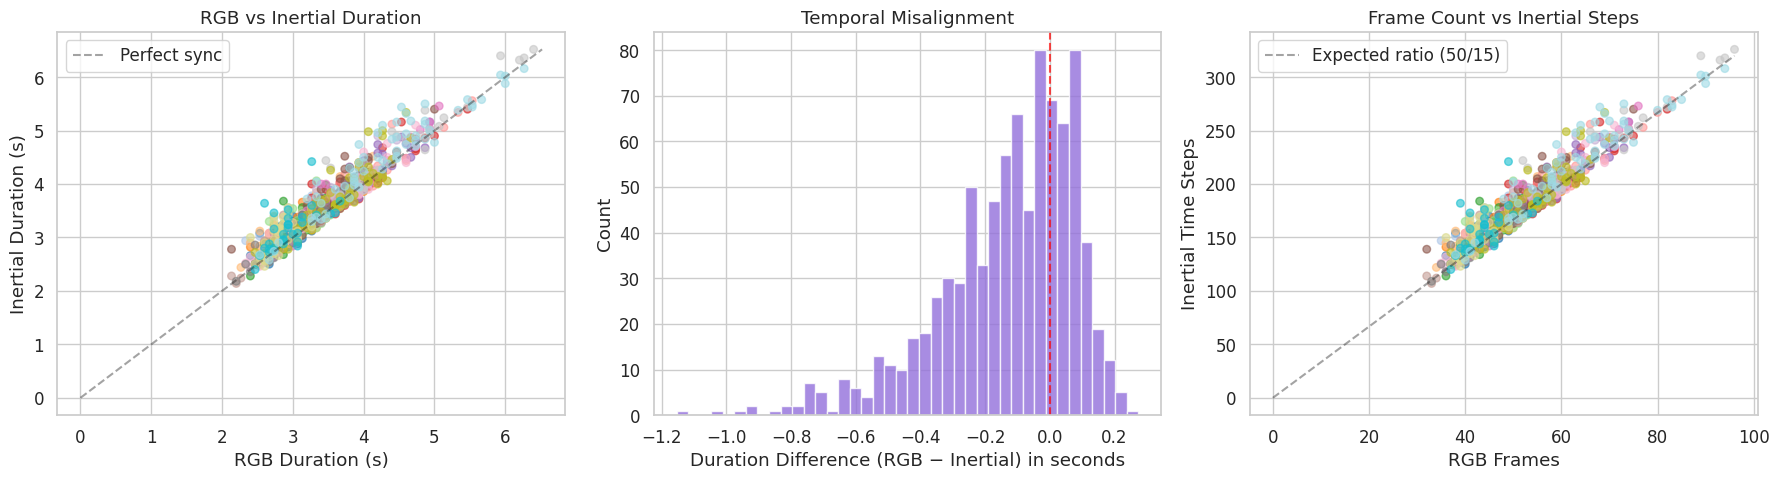

=== Cross-Modal Synchronization ===
Duration difference (RGB − Inertial):
  Mean: -0.132s
  Std:  0.213s
  Max absolute: 1.153s

Samples with >0.5s misalignment: 57
Samples with >1.0s misalignment: 2


In [18]:
# Cross-modal synchronization analysis.
# The RGB camera and inertial sensor were started/stopped independently,
# so the two recordings for the same trial may have slightly different durations.
# We compare them to quantify the temporal misalignment.
both_modalities = df[df['has_rgb'] & df['has_inertial']].copy()
both_modalities['duration_diff'] = both_modalities['rgb_duration'] - both_modalities['inertial_duration']
both_modalities['duration_ratio'] = both_modalities['rgb_duration'] / both_modalities['inertial_duration'].clip(lower=0.01)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LEFT: Scatter of RGB duration vs inertial duration.
# Points on the diagonal (y=x) → perfectly synchronized.
# Points off the diagonal → one modality captured more/less than the other.
scatter = axes[0].scatter(both_modalities['rgb_duration'], both_modalities['inertial_duration'],
                          c=both_modalities['action'], cmap='tab20', alpha=0.6, s=30)
max_dur = max(both_modalities['rgb_duration'].max(), both_modalities['inertial_duration'].max())
axes[0].plot([0, max_dur], [0, max_dur], 'k--', alpha=0.4, label='Perfect sync')
axes[0].set_xlabel('RGB Duration (s)')
axes[0].set_ylabel('Inertial Duration (s)')
axes[0].set_title('RGB vs Inertial Duration')
axes[0].legend()

# MIDDLE: Histogram of (RGB duration − Inertial duration).
# Centered at 0 = good sync; spread shows how much they differ.
axes[1].hist(both_modalities['duration_diff'], bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Duration Difference (RGB − Inertial) in seconds')
axes[1].set_ylabel('Count')
axes[1].set_title('Temporal Misalignment')

# RIGHT: Scatter of raw frame counts vs inertial time-steps.
# If perfectly synced, the ratio should be 50/15 ≈ 3.33 (inertial Hz / RGB Hz).
axes[2].scatter(both_modalities['rgb_frames'], both_modalities['inertial_length'],
                c=both_modalities['action'], cmap='tab20', alpha=0.6, s=30)
f_max = both_modalities['rgb_frames'].max()
axes[2].plot([0, f_max], [0, f_max * 50/15], 'k--', alpha=0.4, label='Expected ratio (50/15)')
axes[2].set_xlabel('RGB Frames')
axes[2].set_ylabel('Inertial Time Steps')
axes[2].set_title('Frame Count vs Inertial Steps')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/cross_modal.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Cross-Modal Synchronization ===')
print(f'Duration difference (RGB − Inertial):')
print(f'  Mean: {both_modalities["duration_diff"].mean():.3f}s')
print(f'  Std:  {both_modalities["duration_diff"].std():.3f}s')
print(f'  Max absolute: {both_modalities["duration_diff"].abs().max():.3f}s')
print(f'\nSamples with >0.5s misalignment: {(both_modalities["duration_diff"].abs() > 0.5).sum()}')
print(f'Samples with >1.0s misalignment: {(both_modalities["duration_diff"].abs() > 1.0).sum()}')

**Data Issue — Temporal Synchronization:** The RGB camera and inertial sensor were recorded on separate channels with independent start/stop times. The analysis above reveals a mean duration mismatch of ~0.13s, with 57 samples exceeding 0.5s misalignment and 2 exceeding 1.0s. In a deployed system, this means naive frame-to-timestep alignment will be incorrect. Fusion strategies must either (a) use timestamps to re-align, (b) resample one modality to match the other, or (c) use architectures that process each modality independently before merging (late fusion).

---
## 7. Data Issues for a Deployed System

Below we summarize and visualize the key data issues discovered through the EDA, and discuss how each might affect a deployed multimodal human activity classification system.

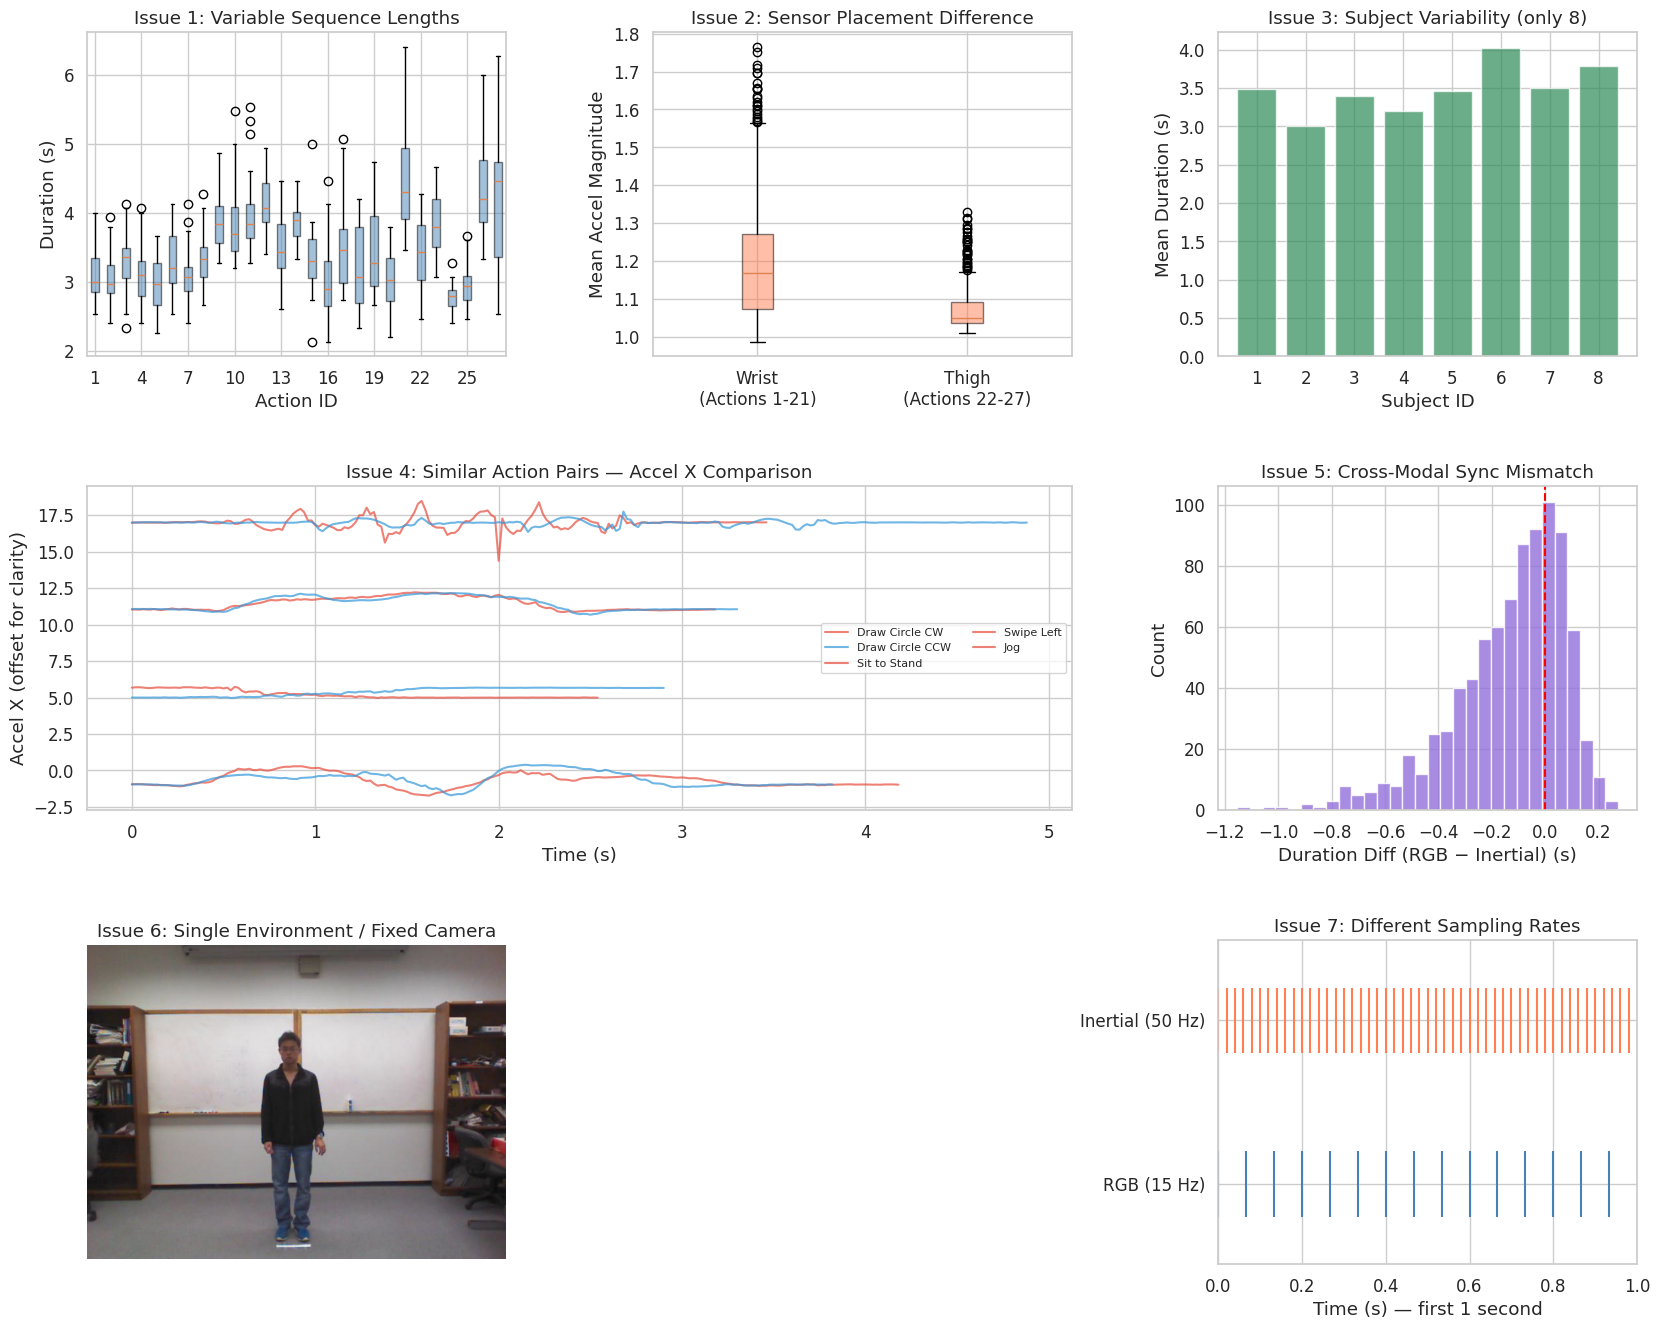

In [21]:
# Summary figure: one subplot per data issue, all in a 3×3 grid.
# This provides a visual overview of the 8 key issues that could affect a deployed system.
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, hspace=0.4, wspace=0.35)

# --- Issue 1: Variable sequence lengths ---
# Box plots show that different actions have very different durations,
# so a fixed-length model input will need padding (adds noise) or truncation (loses info).
ax1 = fig.add_subplot(gs[0, 0])
durations_by_action = [df[df['action'] == a]['rgb_duration'].values for a in sorted(df['action'].unique())]
ax1.boxplot(durations_by_action, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5))
ax1.set_xlabel('Action ID')
ax1.set_ylabel('Duration (s)')
ax1.set_title('Issue 1: Variable Sequence Lengths')
ax1.set_xticks(range(1, 28, 3))
ax1.set_xticklabels(range(1, 28, 3))

# --- Issue 2: Sensor placement difference ---
# The inertial sensor was worn on the wrist for arm actions (1-21)
# and on the thigh for leg actions (22-27). This means the signal
# distributions are fundamentally different between the two groups.
# We compare the mean acceleration magnitude (sqrt(ax²+ay²+az²)) per sample.
ax2 = fig.add_subplot(gs[0, 1])
wrist_data = []
thigh_data = []
for key in all_keys:
    if key not in inertial_index:
        continue
    mat = loadmat(str(inertial_index[key]))
    d_iner = None
    for k, v in mat.items():
        if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim == 2:
            d_iner = v
            break
    if d_iner is not None:
        mag = np.sqrt(np.sum(d_iner[:, :3]**2, axis=1)).mean()
        if key[0] <= 21:
            wrist_data.append(mag)
        else:
            thigh_data.append(mag)

ax2.boxplot([wrist_data, thigh_data], labels=['Wrist\n(Actions 1-21)', 'Thigh\n(Actions 22-27)'],
            patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.5))
ax2.set_ylabel('Mean Accel Magnitude')
ax2.set_title('Issue 2: Sensor Placement Difference')

# --- Issue 3: Limited subject diversity ---
# Only 8 subjects in total (4M, 4F). Each has a different movement speed/style.
# Bar chart shows mean video duration per subject — differences indicate
# individual pacing. With so few subjects, the model risks overfitting to their habits.
ax3 = fig.add_subplot(gs[0, 2])
subject_dur = df.groupby('subject')['rgb_duration'].mean()
ax3.bar(subject_dur.index, subject_dur.values, color='seagreen', alpha=0.7)
ax3.set_xlabel('Subject ID')
ax3.set_ylabel('Mean Duration (s)')
ax3.set_title('Issue 3: Subject Variability (only 8)')
ax3.set_xticks(range(1, 9))

# --- Issue 4: Class similarity ---
# Some action pairs look very similar in sensor data (e.g., draw circle CW vs CCW).
# We overlay the Accel X signal from each pair (subject 1, trial 1) with vertical offsets
# so you can visually compare how similar the raw signals are.
ax4 = fig.add_subplot(gs[1, 0:2])
similar_pairs = [(9, 10, 'Draw Circle CW vs CCW'), (24, 25, 'Sit→Stand vs Stand→Sit'),
                 (1, 2, 'Swipe Left vs Right'), (22, 23, 'Jog vs Walk')]
y_offset = 0
pair_colors = ['#e74c3c', '#3498db']  # red vs blue for each pair member
for a1, a2, label in similar_pairs:
    for trial_idx, (key_match) in enumerate([(a1, 1, 1), (a2, 1, 1)]):
        if key_match in inertial_index:
            mat = loadmat(str(inertial_index[key_match]))
            d_iner = None
            for k, v in mat.items():
                if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim == 2:
                    d_iner = v
                    break
            if d_iner is not None:
                t = np.arange(d_iner.shape[0]) / 50.0
                ax4.plot(t, d_iner[:, 0] + y_offset, color=pair_colors[trial_idx], alpha=0.7,
                         label=f'{ACTION_NAMES[key_match[0]]}' if y_offset == 0 or trial_idx == 0 else '')
    y_offset += 6

ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Accel X (offset for clarity)')
ax4.set_title('Issue 4: Similar Action Pairs — Accel X Comparison')
ax4.legend(fontsize=8, ncol=2)

# --- Issue 5: Temporal synchronization ---
# Histogram of duration mismatch between RGB and inertial for the same trial.
# Ideally all diffs would be 0; in practice there is noticeable spread.
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(both_modalities['duration_diff'], bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
ax5.axvline(0, color='red', linestyle='--')
ax5.set_xlabel('Duration Diff (RGB − Inertial) (s)')
ax5.set_ylabel('Count')
ax5.set_title('Issue 5: Cross-Modal Sync Mismatch')

# --- Issue 6: Environment bias ---
# Show a sample frame to illustrate that all data was recorded in the same
# indoor lab with fixed camera, lighting, and background.
ax6 = fig.add_subplot(gs[2, 0])
key_env = (1, 1, 1)
if key_env in rgb_index:
    cap = cv2.VideoCapture(str(rgb_index[key_env]))
    ret, frame = cap.read()
    cap.release()
    if ret:
        ax6.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax6.set_title('Issue 6: Single Environment / Fixed Camera')
ax6.axis('off')

# --- Issue 7: Sampling rate mismatch ---
# Event plot showing when each sensor captures a sample in the first 1 second.
# RGB captures 15 samples/sec, inertial captures 50 — they don't align 1:1,
# so fusion requires interpolation or separate processing pipelines.
ax8 = fig.add_subplot(gs[2, 2])
t_rgb = np.arange(15) / 15.0   # 15 evenly-spaced ticks in 1 second
t_iner = np.arange(50) / 50.0  # 50 evenly-spaced ticks in 1 second
ax8.eventplot([t_rgb, t_iner], lineoffsets=[1, 2], linelengths=0.4,
              colors=['steelblue', 'coral'])
ax8.set_yticks([1, 2])
ax8.set_yticklabels(['RGB (15 Hz)', 'Inertial (50 Hz)'])
ax8.set_xlabel('Time (s) — first 1 second')
ax8.set_title('Issue 7: Different Sampling Rates')
ax8.set_xlim(0, 1)

plt.savefig('../data/data_issues_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary of Data Issues and Their Impact on Deployment

| # | Issue | Observation | Impact on Deployed System |
|---|-------|-------------|---------------------------|
| 1 | **Variable sequence lengths** | Action durations range widely (some <1s, others >5s). Different actions have very different temporal profiles. | Requires fixed-length input strategy (padding/truncation/subsampling). Padding adds noise; truncation may lose discriminative information. |
| 2 | **Sensor placement difference** | Inertial sensor placed on wrist for actions 1–21 and thigh for actions 22–27. Signal characteristics differ fundamentally between placements. | A model trained on both placements must learn placement-invariant features or handle two distinct signal distributions. In deployment, sensor placement may be unknown or inconsistent. |
| 3 | **Limited subject diversity** | Only 8 subjects (4M, 4F) from a single lab setting. Each person's body proportions, movement speed, and style vary. | High risk of overfitting to these 8 subjects. Model may fail on new users with different body types, ages, or mobility levels. |
| 4 | **Class similarity** | Several action pairs are kinematically similar: Draw Circle CW/CCW, Sit→Stand/Stand→Sit, Swipe Left/Right, Jog/Walk. | Confusion between similar classes leads to unreliable predictions. May need fine-grained temporal features or additional modalities to disambiguate. |
| 5 | **Temporal synchronization** | RGB and inertial recordings have different start/end times, causing duration mismatches between modalities for the same trial. | Fusion strategies must handle temporal misalignment. Naive concatenation of features from misaligned signals degrades performance. |
| 6 | **Environment bias** | All recordings made in a single indoor lab with a fixed camera position, consistent lighting, and clean background. | Model will likely fail in different environments (outdoors, different rooms, varying lighting, cluttered backgrounds). Camera angle changes would break spatial assumptions. |
| 7 | **Different sampling rates** | RGB at 15fps vs. inertial at 50Hz. These cannot be trivially aligned frame-by-frame. | Fusion requires resampling or a model architecture that handles asynchronous inputs (e.g., separate encoders with late fusion). |

---
## Subset Selection for Subsequent Parts

To keep runtime reasonable while providing a challenging classification task, we select **10 diverse action classes** (6 wrist + 4 thigh) covering both sensor placements:

| Action ID | Name | Sensor | Rationale |
|-----------|------|--------|----------|
| 1 | Swipe Left | Wrist | Simple arm gesture |
| 3 | Wave | Wrist | Greeting gesture |
| 4 | Clap | Wrist | Two-hand action, distinctive |
| 7 | Basketball Shoot | Wrist | Complex arm motion |
| 13 | Boxing | Wrist | Repetitive arm action |
| 19 | Knock | Wrist | Fine-grained hand motion |
| 22 | Jog | Thigh | Rhythmic leg action |
| 23 | Walk | Thigh | Steady locomotion |
| 24 | Sit to Stand | Thigh | Transitional action |
| 27 | Squat | Thigh | Repetitive leg action |

The chosen subset covers 6 wrist actions and 4 thigh actions, selected for diversity across gesture types and sensor placements: simple (Swipe Left, Wave), distinctive (Clap), complex (Basketball Shoot), repetitive (Boxing, Knock), and key lower-body activities (Jog, Walk, Sit to Stand, Squat). This exact action ID list is defined in `src/utils/config.py` under SUBSET_ACTIONS.